In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as stats

Statistical Regression Question:

1. What is the lowest HP stat in the entire dataset, and which Pokemon does it belong to? 

In [2]:
pokemon_data = pd.read_csv("data/raw/pokemon_data.csv")

df = pd.read_csv("data/raw/pokemon_data.csv")

In [ ]:
pokemon_data.head()

In [ ]:
pokemon_data.info()

In [5]:
# Alternative: min_hp = df['hp'].min()

df.sort_values(by='hp', ascending=True)

,id,name,height,weight,type_1,type_2,hp,attack,defense,special_attack,special_defense,speed,base_stat_total
291,292,shedinja,8,12,bug,ghost,1,90,45,30,30,40,236
49,50,diglett,2,8,ground,NaN,10,55,25,35,45,95,265
959,960,wiglett,12,18,water,NaN,10,55,25,35,25,95,245
438,439,mime-jr,6,130,psychic,fairy,20,25,45,70,90,60,310
171,172,pichu,3,20,electric,NaN,20,40,15,35,35,60,205
...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,202,wobbuffet,13,285,psychic,NaN,190,33,58,33,58,33,405
894,895,regidrago,21,2000,dragon,NaN,200,100,50,100,50,80,580
798,799,guzzlord,55,8880,dark,dragon,223,101,53,97,53,43,570
112,113,chansey,11,346,normal,NaN,250,5,5,35,105,50,450


In [ ]:
hp_df = df.loc[:, ['name', 'hp']].sort_values(by='hp', ascending=True)

# Alternative: hp_df = df.loc[:, ['name', 'hp']].sort_values(by='hp', ascending=True)
print(hp_df)


           name   hp
0      shedinja    1
1       diglett   10
2       wiglett   10
3       mime-jr   20
4         pichu   20
...         ...  ...
1020  wobbuffet  190
1021  regidrago  200
1022   guzzlord  223
1023    chansey  250
1024    blissey  255

[1025 rows x 2 columns]


<Figure size 640x480 with 0 Axes>

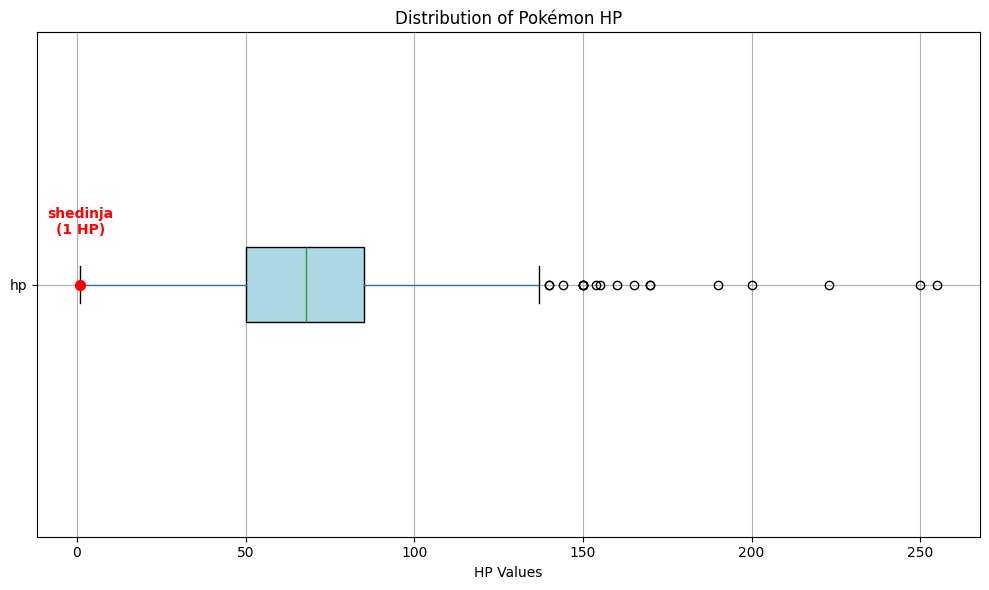

In [109]:
fig = plt.figure()

# Identify the weakest Pokémon
weakest_row = df.loc[df['hp'].idxmin()]
weakest_hp = weakest_row['hp']
weakest_name = weakest_row['name']

fig, ax = plt.subplots(figsize=(10, 6))
# Highlight the outlier point specifically
ax.scatter(weakest_hp, 1, color='red', s=50, zorder=5)

# Create a horizontal boxplot for better readability
df.boxplot(column='hp', vert=False, ax=ax, patch_artist=True, boxprops=dict(facecolor='lightblue'))

ax.text(weakest_hp, 1.1, f'{weakest_name}\n({weakest_hp} HP)', 
        color='red', fontweight='bold', ha='center', fontsize=10)

# Highlight the title
plt.title('Distribution of Pokémon HP')
plt.xlabel('HP Values')

plt.tight_layout()
plt.show()

# df_hist = pd.DataFrame({'hp': np.random.randint(10, 100, 250)})
# df_hist['hp'].plot(kind='hist', bins=40, edgecolor='black')
# plt.title('Pokemon HP Distribution')
# plt.xlabel("Hit Points (HP)")
# plt.show()


In [ ]:
lowest_hp = df['hp'].min()
print(df.loc[[291], ['name', 'hp']])

         name  hp
291  shedinja   1


In [ ]:
weak_pokemon = df.loc[291, 'name']
print(f"The lowest HP stat in the entire dataset is {lowest_hp} HP which belongs to {weak_pokemon}.") 


The lowest HP stat in the entire dataset is 1 HP which belongs to shedinja.


ANSWER: The lowest HP stat in the entire dataset is 1 HP which belongs to shedinja.

2. What is the average HP across all Pokemon?

In [ ]:
total_avg = df['hp'].mean().round(2)

print(f'The average HP across all Pokemon is, {total_avg}.')

The average HP across all Pokemon is, 70.18


Answer: The average HP across all Pokemon is, 70.18.

Text(0.5, 0, 'Hit Points (HP)')

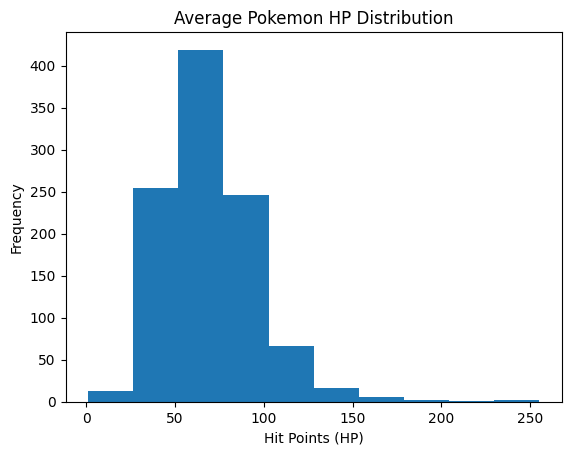

In [87]:
df.groupby('name')['hp'].mean().plot(kind='hist')
plt.title('Average Pokemon HP Distribution')
plt.xlabel("Hit Points (HP)")

